In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os


try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv' ))
    print('Thursday data confirmed. :)')

except Exception as e:
    print(f'Something went wrong {e}')

data.head()

Thursday data confirmed. :)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN


In [2]:
data.columns = data.columns.str.strip()

print(data.shape)

print(data.dtypes)

(288602, 79)
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object


In [3]:
print(data.isnull().sum())
print('----')
print(data['Label'].value_counts())

num_port = {}
count = {}

for label, port in zip(data['Label'], data['Destination Port']):
    if label not in num_port:
        num_port[label] = []
    num_port[label].append(port)

for label, ports in num_port.items():
    count = {}
    for port in ports:
        if port not in count:
            count[port] = 0
        count[port] += 1
    most_common_port = max(count, key=count.get)
    least_common_port = min(count, key=count.get)
    other_ports = [port for port, hits in count.items() if port not in [most_common_port, least_common_port]]
    print(f"Label: {label}, Most Common Destination Port: {most_common_port}, Hits: {count[most_common_port]}")
    print(f"Label: {label}, Least Common Destination Port: {least_common_port}, Hits: {count[least_common_port]}")
    print(f"Label: {label}, Other Destination Ports: {other_ports}")
    print("-----")

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64
----
Label
BENIGN          288566
Infiltration        36
Name: count, dtype: int64
Label: BENIGN, Most Common Destination Port: 53, Hits: 99311
Label: BENIGN, Least Common Destination Port: 63216, Hits: 1
Label: BENIGN, Other Destination Ports: [22, 60148, 123, 0, 443, 80, 55580, 55575, 21, 38118, 53431, 53430, 55543, 55480, 55449, 55544, 55572, 389, 55457, 55487, 55551, 55506, 55538, 55482, 55494, 55537, 55510, 55498, 35203, 52083, 37016, 52365, 52387, 52388, 52386, 52397, 52399, 52432, 52429, 52437, 52439, 52449, 63220, 52363, 63221, 52395, 52407, 52381, 52405, 52406, 52368, 52470, 445, 52417, 52403, 52

In [4]:

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1'
]


data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57669
           1       0.88      0.70      0.78        10

    accuracy                           1.00     57679
   macro avg       0.94      0.85      0.89     57679
weighted avg       1.00      1.00      1.00     57679



Bwd Packet Length Max          0.050216
Destination Port               0.047712
Bwd Packet Length Mean         0.047544
Subflow Fwd Bytes              0.040306
Avg Bwd Segment Size           0.040068
Total Length of Bwd Packets    0.036595
Total Length of Fwd Packets    0.035421
Subflow Bwd Bytes              0.025702
Fwd Packet Length Std          0.024673
Init_Win_bytes_forward         0.023161
dtype: float64


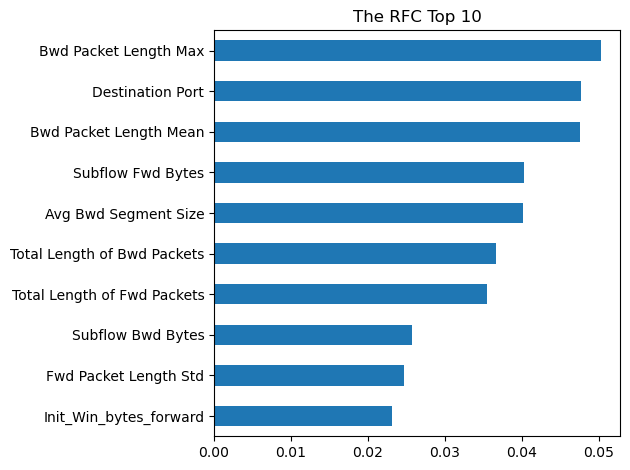

In [7]:
import matplotlib.pyplot as plt

rfc_importance = RandomForestClassifier(n_estimators = 100, random_state=1)
rfc_importance.fit(X,y)

importance = pd.Series(rfc_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).sort_values().plot(kind='barh')
plt.title('The RFC Top 10')
plt.tight_layout()
plt.show()